In [1]:
from pprint import pprint

from shapely import geometry
from pystac_client import Client
import pandas as pd
import geopandas as gpd
import xarray as xr
from distributed import LocalCluster

Setup


In [2]:
# Create local processing cluster
cluster = LocalCluster()
client = cluster.get_client()

harz_boundaries = gpd.read_file("../resources/Nationalpark_Harz_boundaries.geojson")
#bbox = harz_boundaries.geometry.values[0].bounds
bbox = [10.633501, 51.611195, 10.787234, 51.698098]

bbox_polygon = geometry.box(*bbox)
polygon = gpd.GeoDataFrame(index=[0], crs="epsg:4326", geometry=[bbox_polygon])

epsg = 32632  # Sentinel-2 data CRS known a priori
bbox_reproj = polygon.to_crs("epsg:" + str(epsg)).geometry.values[0].bounds

x_slice = slice(bbox_reproj[0], bbox_reproj[2])  # ~100 pixels
y_slice = slice(bbox_reproj[3], bbox_reproj[1])  # ~100 pixels


catalog = Client.open("https://stac.core.eopf.eodc.eu")

In [3]:
def get_item_for_year(year):
    results = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox,
        datetime=[f"{year}-06-01", f"{year}-08-30"],
        query={"eo:cloud_cover": {"lt": 30}},  # optional filter
    )
    items = results.item_collection()
    if not items:
        return None

    # pick least cloudy item to get better images.
    best_item = min(items, key=lambda x: x.properties.get("eo:cloud_cover", 999))

    print(f"{year}: selected item with cloud cover = {best_item.properties.get("eo:cloud_cover", "unknown")}%")

    return best_item

CloudCover is in properties, so we can select it from here.

In [4]:
#TODO: Change this to a function
years = range(2019, 2026)

items = [
    item for year in years
    if (item := get_item_for_year(year)) is not None
]
sr_datasets = []

for item in items:
    # Open SR_20m asset for this item
    ds = xr.open_dataset(item.assets["SR_10m"].href, engine="eopf-zarr", chunks={})

    # Expand a time dimension using the item's timestamp
    ds = ds.expand_dims(time=pd.to_datetime([item.datetime]).tz_localize(None))

    sr_datasets.append(ds)

# Combine all items into one Dataset along time
r10m = xr.concat(sr_datasets, dim="time", join="outer")
r10m

2019: selected item with cloud cover = 0.006149%
2020: selected item with cloud cover = 1.216421%
2021: selected item with cloud cover = 9.860844%
2022: selected item with cloud cover = 0.001319%
2023: selected item with cloud cover = 0.294418%
2025: selected item with cloud cover = 0.002405%


<xarray.Dataset> Size: 23GB
Dimensions:      (time: 6, y: 10980, x: 10980)
Coordinates:
  * time         (time) datetime64[ns] 48B 2019-06-29T10:30:31.024000 ... 202...
  * y            (y) int64 88kB 5800015 5800005 5799995 ... 5690235 5690225
  * x            (x) int64 88kB 600005 600015 600025 ... 709775 709785 709795
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b03          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b04          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b08          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>

In [5]:
import xarray as xr
import zarr
import dask.array as da
import pandas as pd

items = [
    item for year in years
    if (item := get_item_for_year(year)) is not None
]
sr_datasets = []


for item in items:
    # ------------------------------------------------------------------
    # 1. Open SR_20m
    # ------------------------------------------------------------------
    ds = xr.open_dataset(
        item.assets["SR_20m"].href,
        engine="eopf-zarr",
        chunks={}
    )

    # ------------------------------------------------------------------
    # 2. Open SCL_20m as a Dask-backed DataArray
    # ------------------------------------------------------------------
    scl_z = zarr.open(item.assets["SCL_20m"].href, mode="r")
    scl_da = xr.DataArray(
        da.from_array(scl_z, chunks=scl_z.chunks),
        dims=("y", "x"),
        name="scl"
    )

    # ------------------------------------------------------------------
    # 3. Add SCL as a new variable to the dataset
    # ------------------------------------------------------------------
    ds = ds.assign(scl=scl_da)

    # ------------------------------------------------------------------
    # 4. Add time dimension consistent with SR dataset
    # ------------------------------------------------------------------
    ds = ds.expand_dims(time=[pd.to_datetime(item.datetime).tz_localize(None)])

    sr_datasets.append(ds)

# ----------------------------------------------------------------------
# 5. Combine all datasets into a single time stack
# ----------------------------------------------------------------------
r20m_mask_l2a_classification = xr.concat(sr_datasets, dim="time", join="outer")
r20m_mask_l2a_classification

2019: selected item with cloud cover = 0.006149%
2020: selected item with cloud cover = 1.216421%
2021: selected item with cloud cover = 9.860844%
2022: selected item with cloud cover = 0.001319%
2023: selected item with cloud cover = 0.294418%
2025: selected item with cloud cover = 0.002405%


<xarray.Dataset> Size: 15GB
Dimensions:      (time: 6, y: 5490, x: 5490)
Coordinates:
  * time         (time) datetime64[ns] 48B 2019-06-29T10:30:31.024000 ... 202...
  * y            (y) int64 44kB 5800010 5799990 5799970 ... 5690250 5690230
  * x            (x) int64 44kB 600010 600030 600050 ... 709750 709770 709790
    spatial_ref  int64 8B 0
Data variables:
    b01          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b02          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b03          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b04          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b05          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b06          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b07          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b11          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b12          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b8a          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    scl          (time, y, x) uint8 181MB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>

In [6]:
item

<Item id=S2C_MSIL2A_20250813T102041_N0511_R065_T32UPC_20250813T160110>

In [7]:
factor = 10
r100m = r10m.coarsen(x=factor, y=factor, boundary="trim").mean()
r100m.sel()

<xarray.Dataset> Size: 231MB
Dimensions:      (time: 6, y: 1098, x: 1098)
Coordinates:
  * time         (time) datetime64[ns] 48B 2019-06-29T10:30:31.024000 ... 202...
  * y            (y) float64 9kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 9kB 6e+05 6.002e+05 ... 7.096e+05 7.098e+05
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 58MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>
    b03          (time, y, x) float64 58MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>
    b04          (time, y, x) float64 58MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>
    b08          (time, y, x) float64 58MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>

In [8]:
target_chunks = {dim: ch[0] for dim, ch in zip(r100m["b02"].dims, r100m["b02"].chunks)}

# Interpolate and rechunk the SCL layer
scl_100m = (
    r20m_mask_l2a_classification.scl
    .chunk({"x": -1, "y": -1})  # merge chunks along x and y for interpolation
    .interp(x=r100m["x"], y=r100m["y"], method="nearest")
    .chunk(target_chunks)        # apply target chunks from r100m
)
# TODO: Why not coarse this aswell? Is it because we have to interpolate anyhow, because of resolution?
scl_100m

<xarray.DataArray 'scl' (time: 6, y: 1098, x: 1098)> Size: 58MB
dask.array<rechunk-merge, shape=(6, 1098, 1098), dtype=float64, chunksize=(1, 183, 183), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 48B 2019-06-29T10:30:31.024000 ... 202...
  * y            (y) float64 9kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 9kB 6e+05 6.002e+05 ... 7.096e+05 7.098e+05
    spatial_ref  int64 8B 0

In [9]:
def validate_scl(scl):
    """
    Create a boolean mask for valid pixels based on the Scene Classification Layer (SCL).

    Returns
    -------
    valid_mask : xarray.DataArray (bool)
        True for pixels considered valid for analysis, False for invalid pixels.
    """

    # Sentinel-2 SCL classes
    scl_classes = {
        0: "No data",                 # No observation
        1: "Saturated / defective",   # Sensor issues
        2: "Dark area pixels",        # Very low reflectance (shadowed)
        3: "Cloud shadows",           # Pixels in shadow of clouds
        4: "Vegetation",              # Green vegetation
        5: "Bare soil",               # Soil / sand / non-vegetated areas
        6: "Water",                   # Lakes, rivers, ocean
        7: "Unclassified",            # Could not classify
        8: "Cloud medium probability",# Clouds detected with medium confidence
        9: "Cloud high probability",  # Clouds detected with high confidence
        10: "Thin cirrus",            # High altitude thin clouds
        11: "Snow / ice"              # Snow or ice cover
    }

    # Define which SCL classes are considered invalid for analysis
    # (common for NDVI / vegetation analysis)
    invalid_classes = [0, 1, 2, 3, 7, 8, 9, 10, 11]

    # Create boolean mask: True = valid, False = invalid
    valid_mask = ~scl.isin(invalid_classes)

    return valid_mask
valid_mask = validate_scl(scl_100m)
valid_r100m = r100m.where(valid_mask) # Applying the mask
valid_r100m = r100m

Problem: Maybe the data we are using is obstructed by clouds e.g. and is being thrown out of the Mask?


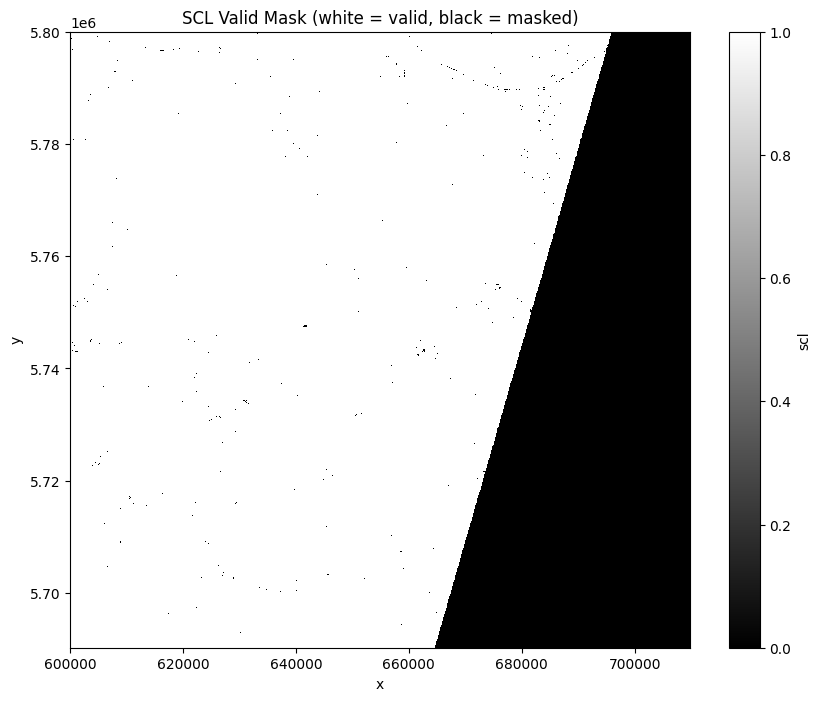

In [10]:
import matplotlib.pyplot as plt

# If it has a time dimension, pick the first timestep
mask_slice = valid_mask.isel(time=0) if "time" in valid_mask.dims else valid_mask

plt.figure(figsize=(10, 8))
mask_slice.plot(cmap="gray")  # True will be white, False black
plt.title("SCL Valid Mask (white = valid, black = masked)")
plt.show()


In [11]:
mask_ratio = (~valid_mask).sum() / valid_mask.size
print(f"Fraction of pixels masked: {mask_ratio.values:.2%}")

Fraction of pixels masked: 20.77%


Result: Too little pixels removed for it to mess up the data that much.


In [12]:
from datetime import datetime

# Stack bands and NDVI, scale to match Sentinel Hub
# Not sure if we need to concat in this way? can keep it as data arrays in the dataset may be here??
reflectances_r100m = valid_r100m

def scale_band(da):
    attrs = da.attrs.get("_eopf_attrs", {})
    scale = attrs.get("scale_factor", 1.0)
    offset = attrs.get("add_offset", 0.0)
    return da * scale + offset

#reflectances_r100m = xr.Dataset({
#    band: scale_band(valid_r100m[band])
#    for band in ["b04", "b08"]
#})

reflectances_r100m["ndvi"] = (reflectances_r100m.b08 - reflectances_r100m.b04) / (reflectances_r100m.b08 + reflectances_r100m.b04)

#TODO: Take EPSG from satellite data
#TODO: Check, whether every offset and scale matches.

cloudless_bands_ndvi = reflectances_r100m.sel(
    time=datetime(2018, 6, 4), method="nearest"
)

region = cloudless_bands_ndvi.sel(x=x_slice, y=y_slice).chunk(
    {"y": "auto", "x": "auto"}
)

ndvi_region = region["ndvi"].compute()

yearly_ds = (
    reflectances_r100m.sel(x=x_slice, y=y_slice)
    .groupby("time.year")
    .mean(dim="time", skipna=True)
)
yearly_ds

<xarray.Dataset> Size: 3MB
Dimensions:      (year: 6, y: 100, x: 109)
Coordinates:
  * year         (year) int64 48B 2019 2020 2021 2022 2023 2025
  * y            (y) float64 800B 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
  * x            (x) float64 872B 6.13e+05 6.13e+05 ... 6.236e+05 6.238e+05
    spatial_ref  int64 8B 0
Data variables:
    b02          (year, y, x) float64 523kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>
    b03          (year, y, x) float64 523kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>
    b04          (year, y, x) float64 523kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>
    b08          (year, y, x) float64 523kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>
    ndvi         (year, y, x) float64 523kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>

In [13]:
#reflectances_r100m.b04.min().compute(), reflectances_r100m.b04.max().compute()


In [14]:
#NDVI for selected region.
ndvi_region.min().item(), ndvi_region.max().item(), ndvi_region.mean().item()

(0.20710846756163756, 0.9336214973073391, 0.8263470939207497)

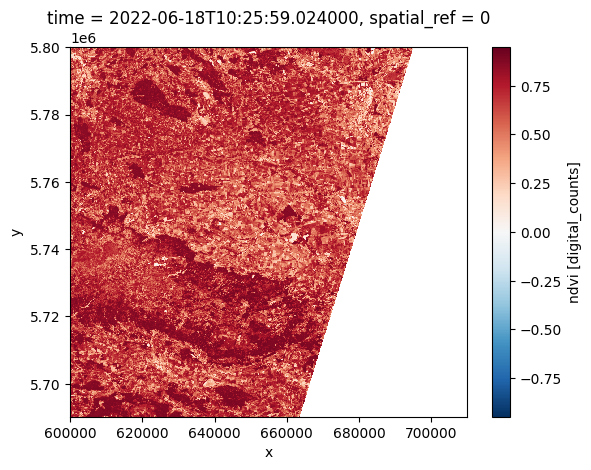

In [15]:
reflectances_r100m.ndvi.isel(time=3).plot()

In [16]:
def plot_rgb_ndvi(dset, x_slice, y_slice):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # First subplot
    rgb = dset[["b04", "b03", "b02"]].to_dataarray(dim="bands")
    rgb = (rgb - 0.02) / (0.35 - 0.02)  # Stretch 0.02-0.35 to 0-1
    rgb = rgb.clip(0, 1)  # Clip to valid range
    rgb.plot.imshow(
        ax=ax1,
        rgb="bands",
        extent=(x_slice.start, x_slice.stop, y_slice.start, y_slice.stop),
    )
    ax1.set_title("RGB (Enhanced)")

    # Second plot
    ndvi_plot = dset["ndvi"].plot(
        ax=ax2, cmap="Greens", vmin=-1, vmax=1, add_colorbar=False
    )
    ax2.set_title("NDVI")

    # Add color bar on the right
    fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
    fig.colorbar(ndvi_plot, cax=cbar_ax)

In [17]:
year = 2020
region = yearly_ds.sel(year=year)

region

<xarray.Dataset> Size: 438kB
Dimensions:      (y: 100, x: 109)
Coordinates:
  * y            (y) float64 800B 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
  * x            (x) float64 872B 6.13e+05 6.13e+05 ... 6.236e+05 6.238e+05
    spatial_ref  int64 8B 0
    year         int64 8B 2020
Data variables:
    b02          (y, x) float64 87kB dask.array<chunksize=(22, 54), meta=np.ndarray>
    b03          (y, x) float64 87kB dask.array<chunksize=(22, 54), meta=np.ndarray>
    b04          (y, x) float64 87kB dask.array<chunksize=(22, 54), meta=np.ndarray>
    b08          (y, x) float64 87kB dask.array<chunksize=(22, 54), meta=np.ndarray>
    ndvi         (y, x) float64 87kB dask.array<chunksize=(22, 54), meta=np.ndarray>

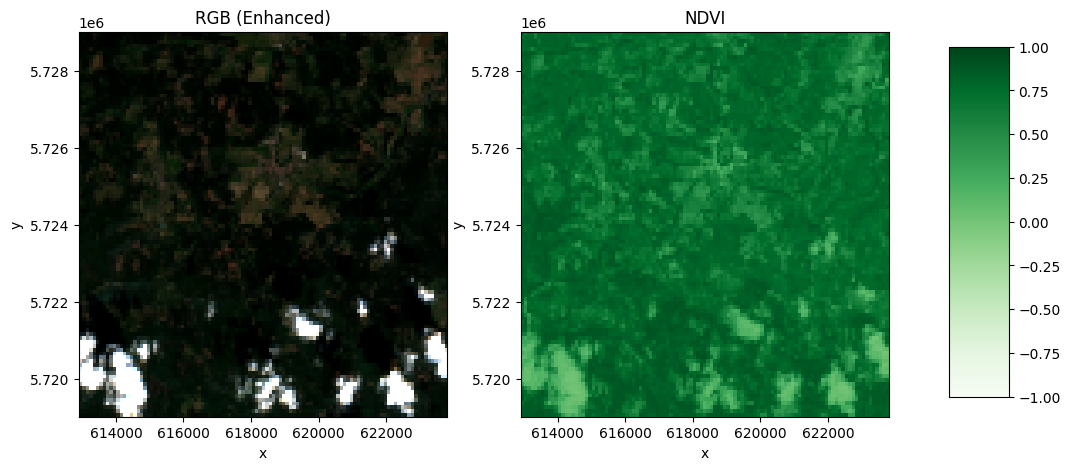

In [18]:
plot_rgb_ndvi(region, x_slice, y_slice)

In [19]:
yearly_ds

<xarray.Dataset> Size: 3MB
Dimensions:      (year: 6, y: 100, x: 109)
Coordinates:
  * year         (year) int64 48B 2019 2020 2021 2022 2023 2025
  * y            (y) float64 800B 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
  * x            (x) float64 872B 6.13e+05 6.13e+05 ... 6.236e+05 6.238e+05
    spatial_ref  int64 8B 0
Data variables:
    b02          (year, y, x) float64 523kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>
    b03          (year, y, x) float64 523kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>
    b04          (year, y, x) float64 523kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>
    b08          (year, y, x) float64 523kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>
    ndvi         (year, y, x) float64 523kB dask.array<chunksize=(1, 22, 54), meta=np.ndarray>

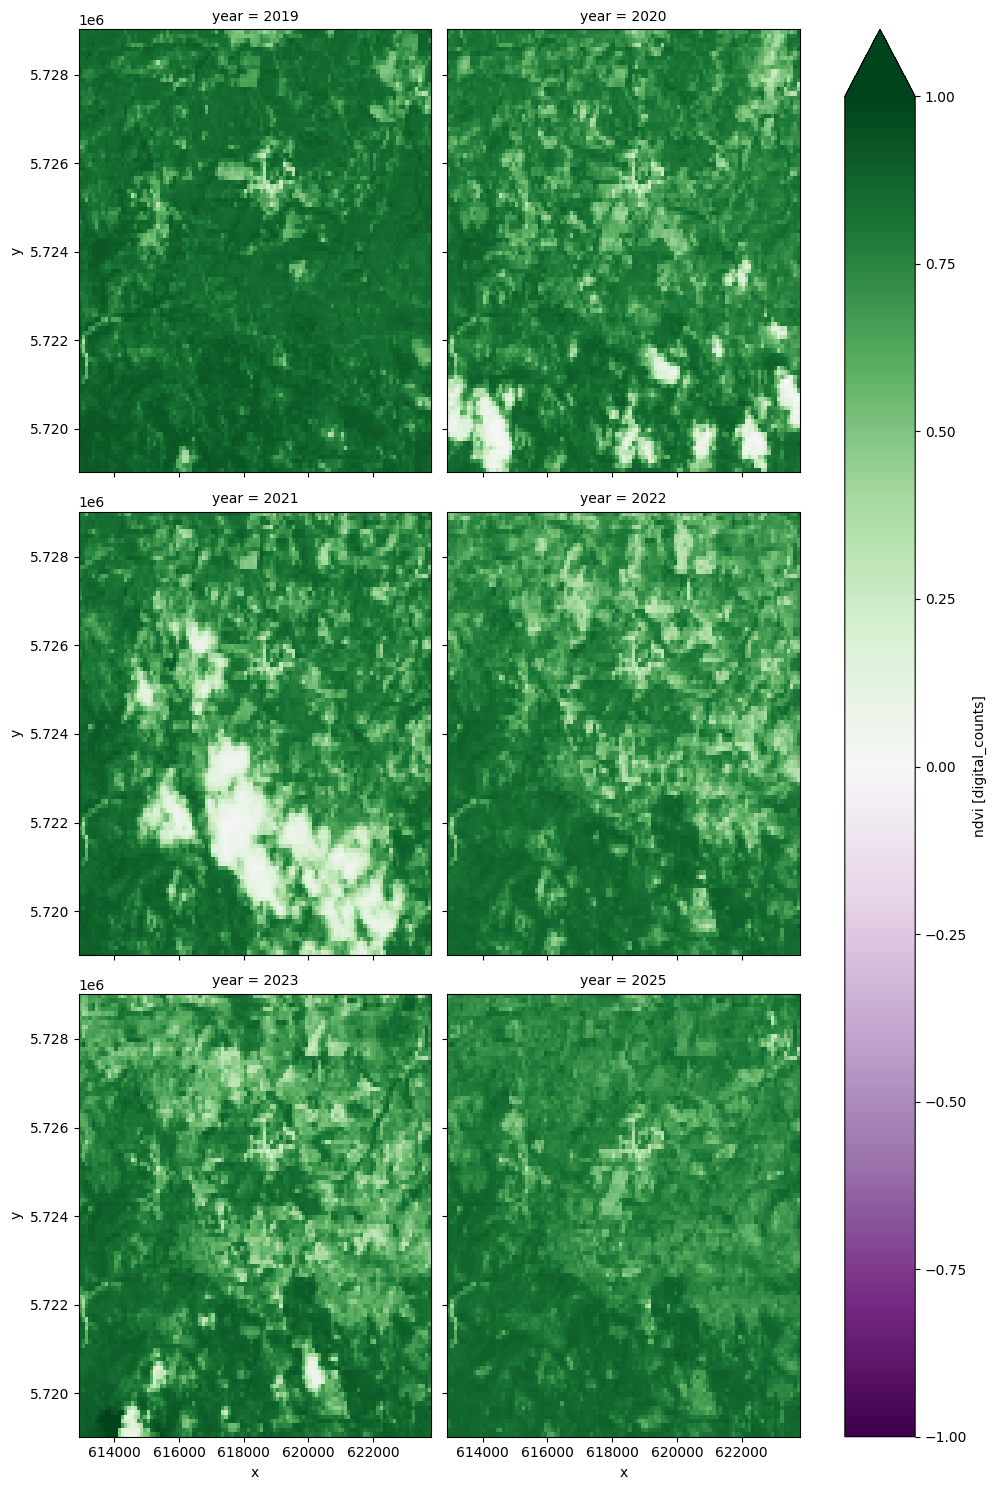

In [20]:
ndvi_yearly = yearly_ds["ndvi"].sel(x=x_slice, y=y_slice).sel(
    year=slice(2018, 2025)
)

ndvi_yearly.plot(
    cmap="PRGn", x="x", y="y", col="year", col_wrap=2, vmin=-1, vmax=1, figsize=(10, 15)
)

In [21]:
yearly_ds.ndvi.values

array([[[0.8357126 , 0.85334637, 0.85653879, ..., 0.84265191,
         0.86546353, 0.91086855],
        [0.8450441 , 0.83798136, 0.85222329, ..., 0.89479827,
         0.87172051, 0.86347237],
        [0.85417087, 0.84574101, 0.86681336, ..., 0.88072172,
         0.87768605, 0.70588903],
        ...,
        [0.88864943, 0.9070245 , 0.91136582, ..., 0.90461391,
         0.89766516, 0.84872459],
        [0.89934526, 0.90293477, 0.91947827, ..., 0.88892009,
         0.88716423, 0.87326578],
        [0.89547354, 0.91439616, 0.9188989 , ..., 0.89798592,
         0.86108256, 0.85233114]],

       [[0.78      , 0.71855049, 0.80994441, ..., 0.50308136,
         0.62642469, 0.85706401],
        [0.70804728, 0.79226457, 0.80418597, ..., 0.77884072,
         0.77350491, 0.85241655],
        [0.80383943, 0.7884245 , 0.81998452, ..., 0.84195397,
         0.82559026, 0.80779653],
        ...,
        [0.80602526, 0.8499323 , 0.86479288, ..., 0.8351012 ,
         0.85204546, 0.81828467],
        [0.8

In [22]:
import numpy as np
yearly_ds.ndvi.load()
yearly_ds["FOREST"] = yearly_ds.ndvi > 0.7

def to_km2(dataarray, resolution):
    # Calculate forest area
    return dataarray * np.prod(list(resolution)) / 1e6

#TODO: Remove resolution variable in favor of slice-size
resolution = (100, 100)
forest_pixels = yearly_ds.sel(x=x_slice, y=y_slice).FOREST.sum(["x", "y"])
forest_area_km2 = to_km2(forest_pixels, resolution)
forest_area_km2


<xarray.DataArray 'FOREST' (year: 6)> Size: 48B
array([100.37,  76.44,  65.97,  68.81,  66.01,  88.7 ])
Coordinates:
  * year         (year) int64 48B 2019 2020 2021 2022 2023 2025
    spatial_ref  int64 8B 0
Attributes: (12)

In [23]:
yearly_ds["FOREST"]

forest_area_km2.load()


<xarray.DataArray 'FOREST' (year: 6)> Size: 48B
array([100.37,  76.44,  65.97,  68.81,  66.01,  88.7 ])
Coordinates:
  * year         (year) int64 48B 2019 2020 2021 2022 2023 2025
    spatial_ref  int64 8B 0
Attributes: (12)

In [24]:
yearly_ds.ndvi

<xarray.DataArray 'ndvi' (year: 6, y: 100, x: 109)> Size: 523kB
array([[[0.8357126 , 0.85334637, 0.85653879, ..., 0.84265191,
         0.86546353, 0.91086855],
        [0.8450441 , 0.83798136, 0.85222329, ..., 0.89479827,
         0.87172051, 0.86347237],
        [0.85417087, 0.84574101, 0.86681336, ..., 0.88072172,
         0.87768605, 0.70588903],
        ...,
        [0.88864943, 0.9070245 , 0.91136582, ..., 0.90461391,
         0.89766516, 0.84872459],
        [0.89934526, 0.90293477, 0.91947827, ..., 0.88892009,
         0.88716423, 0.87326578],
        [0.89547354, 0.91439616, 0.9188989 , ..., 0.89798592,
         0.86108256, 0.85233114]],

       [[0.78      , 0.71855049, 0.80994441, ..., 0.50308136,
         0.62642469, 0.85706401],
        [0.70804728, 0.79226457, 0.80418597, ..., 0.77884072,
         0.77350491, 0.85241655],
        [0.80383943, 0.7884245 , 0.81998452, ..., 0.84195397,
         0.82559026, 0.80779653],
...
        [0.8699703 , 0.88338757, 0.90251658, ..., 0.87851329,
         0.8808183 , 0.85591851],
        [0.87607837, 0.88520819, 0.90807848, ..., 0.87093827,
         0.8725672 , 0.86936555],
        [0.88244574, 0.89868804, 0.90384794, ..., 0.8868428 ,
         0.85071019, 0.85628705]],

       [[0.62184554, 0.70205425, 0.75124143, ..., 0.72855138,
         0.78478481, 0.84434012],
        [0.70992025, 0.75720869, 0.73159028, ..., 0.81198375,
         0.8205107 , 0.82872796],
        [0.71975489, 0.78039368, 0.77693122, ..., 0.78906905,
         0.82653226, 0.8050252 ],
        ...,
        [0.75667813, 0.83999252, 0.86284436, ..., 0.86465821,
         0.87013478, 0.84814098],
        [0.85032284, 0.85749551, 0.87183729, ..., 0.85418273,
         0.86303323, 0.85913538],
        [0.86447377, 0.87003244, 0.87198172, ..., 0.86135433,
         0.84433574, 0.85612042]]], shape=(6, 100, 109))
Coordinates:
  * year         (year) int64 48B 2019 2020 2021 2022 2023 2025
  * y            (y) float64 800B 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
  * x            (x) float64 872B 6.13e+05 6.13e+05 ... 6.236e+05 6.238e+05
    spatial_ref  int64 8B 0
Attributes: (12)

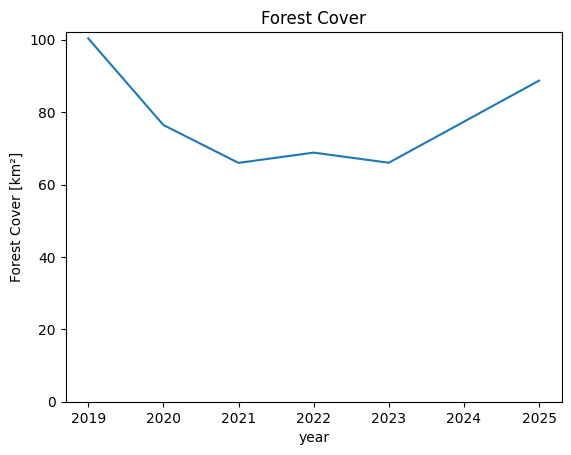

In [25]:
forest_area_km2.plot()

plt.title("Forest Cover")
plt.ylabel("Forest Cover [km²]")
plt.ylim(0);

In [26]:
forest_area_km2

<xarray.DataArray 'FOREST' (year: 6)> Size: 48B
array([100.37,  76.44,  65.97,  68.81,  66.01,  88.7 ])
Coordinates:
  * year         (year) int64 48B 2019 2020 2021 2022 2023 2025
    spatial_ref  int64 8B 0
Attributes: (12)